# SR3 RV Lab — Framework 3: vol vs realized (gamma / theta)

**RV class: C — implied vs delivered on the same contract.**

The only framework where the futures market and the options market disagree
about something neither put-call parity nor the forward can pin: the *size* of
the moves the future will actually make. The trade is an ATM straddle at a
fixed listed strike, delta-hedged **daily on the futures settle** with the
delta observed the previous close.

Signals tested (all premium-native):

* `IV - RV`: listed ATM normal vol minus trailing realized bp vol of the same
  contract's own futures rate.
* `always short`: the unconditional short-gamma benchmark. Every rule has to
  beat this, not zero — the vol-selling literature's own finding is that the
  unconditional short is hard to improve on.
* `vol-return momentum`: sign of the trailing P&L of the always-short program
  (self-referential; no external data).

### The trap this notebook has to avoid

SR3 settles on **compounded SOFR over the reference quarter**. Once the quarter
starts accruing, part of the settlement is already known, so the front
contract's implied vol falls for a purely mechanical reason that has nothing to
do with risk premium. Any IV-vs-RV signal that ranks contracts by vol level
will find enormous fake alpha in the front contract. The cross-sectional work
below is therefore run on contracts with **time to expiry above a floor**, and
the time-to-expiry sensitivity is reported.

In [1]:
CONFIG = dict(
    rv_window=21,             # trailing realized-vol window (business days)
    min_tte=0.15,             # drop contracts inside ~8 weeks of expiry
    min_oi=100,
    contracts_per_leg=100,
    cost_bp=2.5,
    future_leg_bp=0.25,       # charged on every re-hedge, on the traded delta
    rehedge_bands=(0.0, 0.10, 0.25),
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "t20"),
    directions=("fade", "momentum"),
)
CONFIG

{'rv_window': 21,
 'min_tte': 0.15,
 'min_oi': 100,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'future_leg_bp': 0.25,
 'rehedge_bands': (0.0, 0.1, 0.25),
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 't20'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import (
    LabConfig, config_from_row, cost_block, header_block, league_row, load_lab,
    run_framework, three_panel_equity,
)
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, atm_premium_panel,
    constant_maturity_slots, realized_vol_bp, run_backtest,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]

## The ATM straddle panel and the mechanical-decay check

In [3]:
atm = atm_premium_panel(quotes, contracts)
atm = atm.merge(constant_maturity_slots(contracts)[
    ["as_of", "symbol", "tte", "cm_slot", "expiry_date"]],
    on=["as_of", "symbol"], how="left")
print(f"ATM straddle rows: {len(atm)}  symbols: {atm['symbol'].nunique()}")

rv = []
for sym, sub in contracts.sort_values("as_of").groupby("symbol"):
    s = sub.set_index("as_of")["forward_rate"]
    rv.append(pd.DataFrame({"as_of": s.index, "symbol": sym,
                            "rv_bp": realized_vol_bp(s, CONFIG["rv_window"])}))
rv = pd.concat(rv, ignore_index=True)
atm = atm.merge(rv, on=["as_of", "symbol"], how="left")
atm["vrp_bp"] = atm["atm_iv_bp"] - atm["rv_bp"]
atm = add_event_distance(atm)
print(atm.groupby("cm_slot")[["tte", "atm_iv_bp", "rv_bp", "vrp_bp"]]
      .median().round(2).to_string())

ATM straddle rows: 1540  symbols: 7
          tte  atm_iv_bp  rv_bp  vrp_bp
cm_slot                                
1        1.19      84.53  81.86    7.39
2        1.31      89.72  91.11    6.88
3        1.44      90.36  73.41   14.50
4        1.56      86.25  72.25   16.03
5        1.68      97.65  87.28   11.89
6        1.81     101.73  83.71   17.22
7        1.94     101.68  75.49   25.47


The mechanical decay is visible directly: ATM vol against time to expiry. The
front contract's collapse is the accrued-fixings effect, not cheap options.

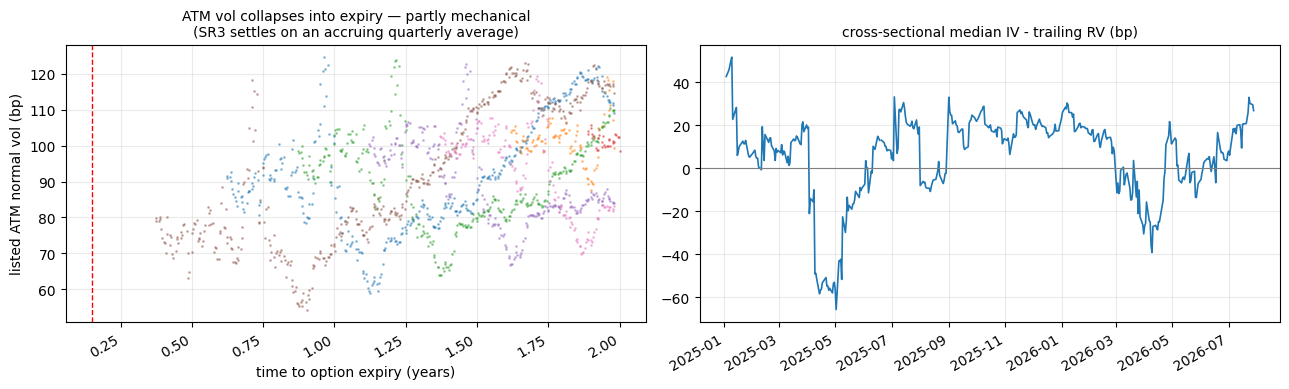

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sym, sub in atm.groupby("symbol"):
    axes[0].plot(sub["tte"], sub["atm_iv_bp"], ".", ms=2, alpha=0.4, label=sym)
axes[0].set_xlabel("time to option expiry (years)")
axes[0].set_ylabel("listed ATM normal vol (bp)")
axes[0].set_title("ATM vol collapses into expiry — partly mechanical\n"
                  "(SR3 settles on an accruing quarterly average)", fontsize=10)
axes[0].axvline(CONFIG["min_tte"], color="red", ls="--", lw=1)
axes[0].grid(alpha=0.25)
axes[1].plot(atm.groupby("as_of")["vrp_bp"].median(), lw=1.2)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("cross-sectional median IV - trailing RV (bp)", fontsize=10)
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [5]:
panel = atm[atm["tte"] >= CONFIG["min_tte"]].copy()
panel = panel.dropna(subset=["vrp_bp"])
print(f"after the time-to-expiry floor: {len(panel)} rows, "
      f"{panel['symbol'].nunique()} symbols")
print(f"median VRP {panel['vrp_bp'].median():+.1f}bp   "
      f"share IV>RV {(panel['vrp_bp'] > 0).mean():.1%}")

after the time-to-expiry floor: 1470 rows, 7 symbols
median VRP +10.7bp   share IV>RV 69.8%


## The tradeable package

One ATM straddle per contract at the listed strike fixed on the execution
date, delta-hedged daily by the engine. `direction=+1` is LONG the straddle
(long gamma, paying theta); `fade` on a rich IV-minus-RV signal therefore sells
gamma, which is the direction the literature says carries the premium.

In [6]:
STRIKE = panel.set_index(["symbol", "as_of"])["atm_strike"].sort_index()


def builder(key, exec_date, direction):
    try:
        k = float(STRIKE.loc[(key, exec_date)])
    except (KeyError, TypeError):
        return None
    return Structure((Leg("option", key, 1.0, "C", k),
                      Leg("option", key, 1.0, "P", k)),
                     label=f"straddle {key}@{k:g}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=CONFIG["future_leg_bp"],
                 rehedge_band=0.0)

sig_vrp = panel.rename(columns={"symbol": "key"})[
    ["key", "as_of", "vrp_bp", "tte", "days_to_fomc"]].copy()
sig_vrp["signal"] = sig_vrp["vrp_bp"]
sig_vrp["gate"] = True

GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

## Benchmark first: the unconditional short-gamma program

Sell every contract's ATM straddle every N days, delta-hedge daily, hold to the
horizon. No signal at all. This is the number every rule below must beat.

In [7]:
bench_rows = []
for hold in ("t5", "t10", "t20"):
    for d in ("short", "long"):
        # entry_rule='always' holds ONE side unconditionally. Driving a
        # "benchmark" off a z-score instead would flip the side from bar to bar,
        # which is not a program at all.
        cfg = dataclasses.replace(
            BASE, entry_rule="always", exit_style=hold, entry_every=5,
            direction="fade" if d == "short" else "momentum")
        r = run_backtest(cfg, signals=sig_vrp, book=lab["book"], builder=builder)
        bench_rows.append({"side": d, "hold": hold, **{
            k: r.metrics[k] for k in ("n_trades", "hit_rate", "avg_net_bp",
                                      "total_net_bp", "total_net_usd", "sharpe",
                                      "max_dd_bp")}})
bench = pd.DataFrame(bench_rows).round(3)
print("UNCONDITIONAL GAMMA PROGRAM (delta-hedged daily, no signal)")
print(bench.to_string(index=False))
print("\nA positive 'short' row is the variance risk premium net of hedging "
      "costs; every signal below must beat it, not zero.")

UNCONDITIONAL GAMMA PROGRAM (delta-hedged daily, no signal)
 side hold  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
short   t5       146     0.596       1.317       192.242      480605.75   1.799    -38.950
 long   t5       146     0.062      -6.317      -922.242    -2305605.75  -8.496   -923.798
short  t10        98     0.704       3.493       342.290      855725.00   2.857    -39.469
 long  t10        98     0.020      -8.493      -832.290    -2080725.00  -6.730   -833.845
short  t20        61     0.836       5.867       357.914      894784.00   2.368    -59.524
 long  t20        61     0.033     -10.867      -662.914    -1657284.00  -4.346   -664.469

A positive 'short' row is the variance risk premium net of hedging costs; every signal below must beat it, not zero.


## Signal 1 — IV minus trailing realized vol

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3. Gamma/theta (IV-RV) — grid ===
  108 configs | median -111.81bp | IQR [-181.98, +10.54] | 26% net-positive | best +96.79bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1            120               2.0        t20        16     0.750       6.049        96.789      241971.50   2.172    -30.298
 momentum  10            120               2.0        t20        11     0.727       7.964        87.608      219020.25   2.124    -33.845
 momentum  10            120               2.0        t10        20     0.600       3.882        77.631      194077.75   1.860    -52.673
 momentum  10            120               1.5        t20        19     0.632       3.879        73.710      184276.25   1.358    -42.188
 momentum   5            120               2.0        t20        12     0.667       6.030        72.355      

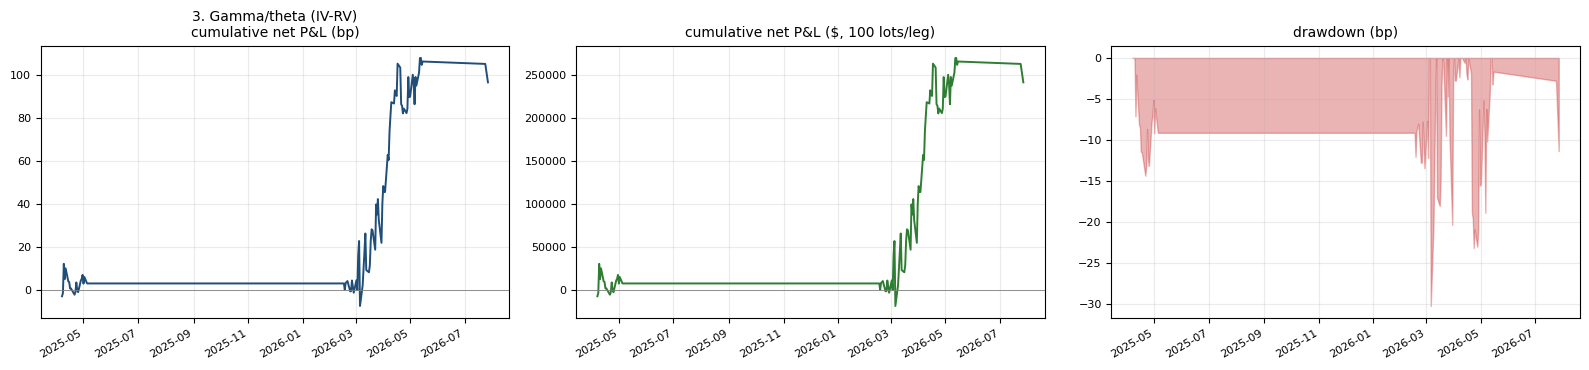


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26   -1  straddle SFRZ26@96.875  2025-04-03 2025-04-04 2025-05-05    20 -2.235    5.5517      2.5  3.0517   7629.17       0.368            2.0        time
SFRM27   -1      straddle SFRM27@97  2026-02-12 2026-02-13 2026-03-13    20 -2.034    5.7751      2.5  3.2751   8187.65       0.466            2.0        time
SFRU27   -1      straddle SFRU27@97  2026-02-12 2026-02-13 2026-03-13    20 -2.245    4.1687      2.5  1.6687   4171.76       0.470            2.0        time
SFRH27   -1  straddle SFRH27@96.875  2026-02-25 2026-02-26 2026-03-26    20 -2.457   10.5630      2.5  8.0630  20157.62       0.486            2.0        time
SFRZ26   -1  straddle SFRZ26@96.875  2026-02-25 2026-02-26 2026-03-26    20 -2.274   18.4812      2.5 15.9812  39953.06       0.495            2.0        time
SFRZ27   -1  straddle 

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        16     0.625       4.347        69.553      173882.25   1.792    -35.953         14.312
half        16     0.625       3.689        59.024      147558.75   1.573    -43.758         13.500
  t5        34     0.559       1.700        57.810      144524.25   1.943    -28.869          4.676
 t10        23     0.478       1.299        29.884       74710.50   0.675    -50.523          8.870
 t20        16     0.750       6.049        96.789      241971.50   2.172    -30.298         16.500

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        16         118.324        78.324   1.613     0.562
       listed    1        16         136.789        96.789   2.172     0.750
same-bar (lag 0) gross inflation: -15.6%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_


3. Gamma/theta (IV-RV) — median config (not selected)  |  momentum|ma5|w120|z1.0|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades    35   skipped    0   hit 34%   avg -3.207bp   avg hold 17.9d   stale 41.0%
  total    -112.24bp   $    -280,601   gross -24.74bp
  daily-MTM Sharpe -1.18   maxDD -185.52bp ($-463,802)   worst trade -20.65bp
  t(trade) -1.62   NW t(daily) -1.26   non-overlap SR -0.64   DSR p=0.000 over 108 trials

  LEAGUE ROW  3. Gamma/theta (IV-RV) / best-config: SELECTION-ARTIFACT  (taker +96.79bp, maker +136.79bp, DSR p=0.015)

  LEAGUE ROW  3. Gamma/theta (IV-RV) / median-config: DEAD  (taker -112.24bp, maker -24.74bp, DSR p=0.000)


In [8]:
out_vrp = run_framework(
    "3. Gamma/theta (IV-RV)", signals=sig_vrp, book=lab["book"], builder=builder,
    base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note=f"ATM straddle, daily delta hedge, tte>={CONFIG['min_tte']}y, "
         f"RV window {CONFIG['rv_window']}d")

## Re-hedge band sensitivity

The literature's claim is that P&L net of costs is maximised at a *modest*
delta band rather than hedging every day. SR3's futures leg is cheap, so the
optimum should be tighter here — this measures it instead of assuming it.

In [9]:
band_rows = []
for band in CONFIG["rehedge_bands"]:
    cfg = dataclasses.replace(out_vrp["config"], rehedge_band=band)
    r = run_backtest(cfg, signals=sig_vrp, book=lab["book"], builder=builder)
    band_rows.append({"rehedge_band": band, **{
        k: r.metrics[k] for k in ("n_trades", "hit_rate", "avg_net_bp",
                                  "total_net_bp", "total_net_usd", "sharpe",
                                  "max_dd_bp")}})
print(pd.DataFrame(band_rows).round(3).to_string(index=False))

 rehedge_band  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
         0.00        16      0.75       6.049        96.789      241971.50   2.172    -30.298
         0.10        16      0.75       5.925        94.805      237012.75   2.235    -29.324
         0.25        16      0.75       5.200        83.201      208002.00   2.093    -28.884


## Signal 2 — vol-return momentum (self-referential, no external data)

Take the daily P&L of the always-short program, and go long gamma when its
trailing return is negative. The highest-information-ratio single signal in the
systematic vol literature; here it is rebuilt from this sample's own P&L.

always-short daily P&L: 403 days, total +357.9bp


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3b. Vol-return momentum — grid ===
  108 configs | median -117.89bp | IQR [-180.71, -45.86] | 7% net-positive | best +90.94bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5             60               1.0        t20        41     0.683       2.218        90.944      227361.00   0.771    -72.357
     fade  10             60               2.0        t20        17     0.647       5.229        88.900      222250.25   1.776    -39.565
 momentum   1             60               1.5        t20        38     0.632       1.342        50.986      127464.75   0.481    -86.489
 momentum  10             60               1.5        t10        49     0.449       0.726        35.572       88928.75   0.490    -65.575
 momentum  10             60               1.0        t10        75     0.507       0.374        28.032      

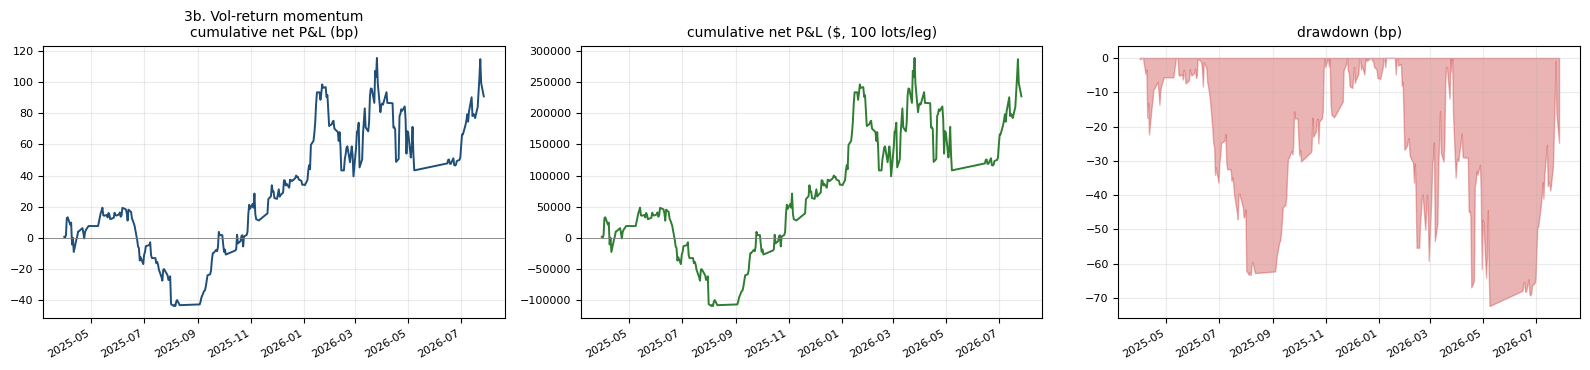


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26   -1  straddle SFRZ26@96.625  2025-03-27 2025-03-28 2025-04-28    20 -1.056    9.9807      2.5   7.4807  18701.77       0.466            2.0        time
SFRZ26   -1   straddle SFRZ26@96.75  2025-05-07 2025-05-08 2025-06-06    20 -1.405   14.2412      2.5  11.7412  29353.05       0.430            2.0        time
SFRH27    1  straddle SFRH27@96.625  2025-06-06 2025-06-09 2025-07-09    20  1.295  -14.3730      2.5 -16.8730 -42182.38       0.486            2.0        time
SFRZ26    1  straddle SFRZ26@96.625  2025-06-09 2025-06-10 2025-07-10    20  1.289  -12.9870      2.5 -15.4870 -38717.54       0.491            2.0        time
SFRH27    1   straddle SFRH27@96.75  2025-07-10 2025-07-11 2025-08-08    20  1.078  -12.2361      2.5 -14.7361 -36840.30       0.441            2.0        time
SFRZ26    1   st

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        55     0.618       1.493        82.115      205286.50   0.740    -65.518         14.182
half        60     0.633       0.447        26.845       67112.25   0.258    -64.034         11.683
  t5       111     0.459      -0.767       -85.082     -212705.50  -0.903   -128.128          5.000
 t10        78     0.513      -0.102        -7.992      -19980.50  -0.071   -103.302          9.692
 t20        41     0.683       2.218        90.944      227361.00   0.771    -72.357         19.561

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        46         168.541        53.541   0.425     0.630
       listed    1        41         193.444        90.944   0.771     0.683
same-bar (lag 0) gross inflation: -14.8%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 41       193.444       4.718     0.707       483611.0
           0.5 41       172.944       4.218     0.683       432361.0
           1.0 41       152.444       3.718     0.683       381111.0
           1.5 41       131.944       3.218     0.683       329861.0
           2.5 41        90.944       2.218     0.683       227361.0
           4.0 41        29.444       0.718     0.634        73611.0



3b. Vol-return momentum — median config (not selected)  |  momentum|ma1|w60|z1.0|t5|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades   124   skipped    0   hit 43%   avg -0.953bp   avg hold 5.0d   stale 43.1%
  total    -118.14bp   $    -295,344   gross +191.86bp
  daily-MTM Sharpe -1.32   maxDD -190.56bp ($-476,403)   worst trade -15.83bp
  t(trade) -2.12   NW t(daily) -1.21   non-overlap SR -0.14   DSR p=0.000 over 108 trials

  LEAGUE ROW  3b. Vol-return momentum / best-config: SELECTION-ARTIFACT  (taker +90.94bp, maker +193.44bp, DSR p=0.000)

  LEAGUE ROW  3b. Vol-return momentum / median-config: MARGINAL-maker-only  (taker -118.14bp, maker +191.86bp, DSR p=0.000)


In [10]:
short_cfg = dataclasses.replace(BASE, entry_rule="always", exit_style="t20",
                                entry_every=5, direction="fade")
short_res = run_backtest(short_cfg, signals=sig_vrp, book=lab["book"],
                         builder=builder)
short_daily = short_res.daily_bp.reindex(
    pd.DatetimeIndex(sorted(sig_vrp["as_of"].unique()))).fillna(0.0)
trail = short_daily.rolling(21, min_periods=10).sum()
print(f"always-short daily P&L: {len(short_daily)} days, "
      f"total {short_daily.sum():+.1f}bp")

sig_mom = sig_vrp.copy()
sig_mom["signal"] = sig_mom["as_of"].map(trail)
sig_mom = sig_mom.dropna(subset=["signal"])
out_mom = run_framework(
    "3b. Vol-return momentum", signals=sig_mom, book=lab["book"], builder=builder,
    base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note="signal = trailing 21d P&L of the always-short gamma program")

## Signal 3 — cross-sectional vol carry

Rank contracts by VRP within each date and trade the extremes against each
other. Removing the date mean strips out the common vol factor, which is what
makes this the highest-power test in the set.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 3c. Cross-sectional vol carry — grid ===
  108 configs | median -111.44bp | IQR [-219.44, +8.11] | 28% net-positive | best +99.64bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1            120               1.0        t20        44     0.750       2.264        99.638      249093.75   1.226    -38.824
 momentum   5            120               1.5        t10        37     0.676       2.310        85.462      213655.75   1.794    -27.265
 momentum  10            120               1.0        t10        54     0.611       1.508        81.422      203555.50   1.246    -39.778
 momentum  10            120               1.5        t10        37     0.676       2.166        80.134      200335.50   1.498    -39.057
 momentum   5             60               2.0        t10        25     0.640       2.896        72.389

3c. Cross-sectional vol carry — best config  |  momentum|ma1|w120|z1.0|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  VRP demeaned across contracts each date
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades    44   skipped    0   hit 75%   avg +2.264bp   avg hold 18.9d   stale 42.8%
  total     +99.64bp   $    +249,094   gross +209.64bp
  daily-MTM Sharpe +1.23   maxDD -38.82bp ($-97,059)   worst trade -29.85bp
  t(trade) +1.50   NW t(daily) +1.60   non-overlap SR +0.15   DSR p=0.000 over 108 trials


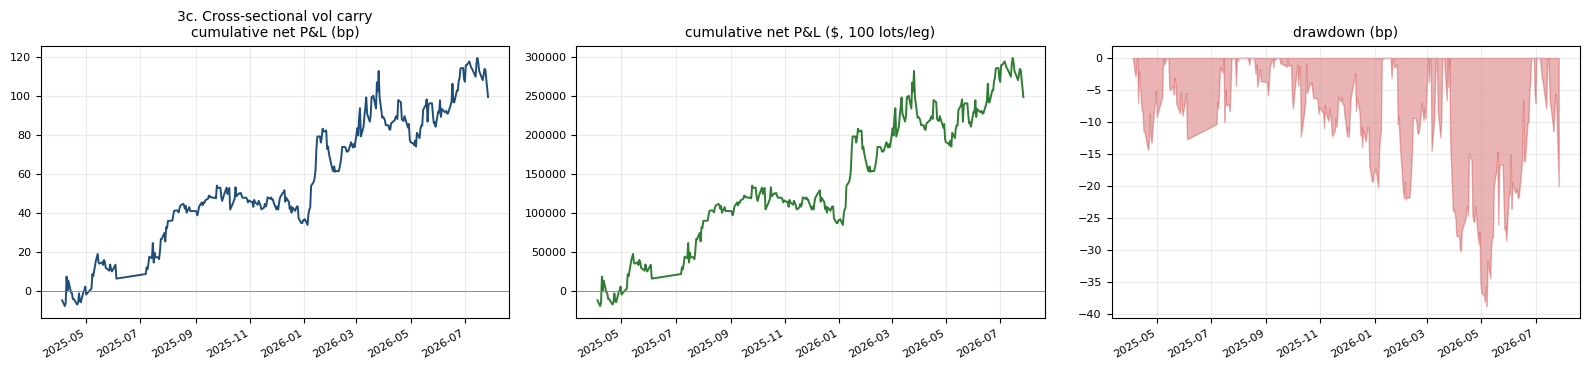


TRADE LOG (first rows)
   key  dir               structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26   -1  straddle SFRZ26@96.875  2025-04-02 2025-04-03 2025-05-02    20 -7.810    1.2647      2.5  -1.2353  -3088.27       0.367            2.0        time
SFRZ26   -1  straddle SFRZ26@96.875  2025-05-05 2025-05-06 2025-06-04    20 -1.576   10.0895      2.5   7.5895  18973.76       0.373            2.0        time
SFRH27   -1  straddle SFRH27@96.875  2025-07-02 2025-07-03 2025-08-01    20 -2.736   17.2432      2.5  14.7432  36857.89       0.351            2.0        time
SFRZ26   -1  straddle SFRZ26@96.875  2025-07-02 2025-07-03 2025-08-01    20 -4.179   17.3797      2.5  14.8797  37199.37       0.369            2.0        time
SFRZ26   -1      straddle SFRZ26@97  2025-08-04 2025-08-05 2025-09-03    20 -2.231    4.9268      2.5   2.4268   6067.08       0.427            2.0        time
SFRM27   -1     

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        70     0.414       0.006         0.416        1040.50   0.006    -47.854          9.471
half        83     0.446      -0.469       -38.905      -97263.50  -0.583    -82.303          6.819
  t5       106     0.462      -0.711       -75.338     -188346.00  -1.058    -98.733          4.962
 t10        70     0.500      -0.599       -41.946     -104865.25  -0.590    -72.391          9.786
 t20        44     0.750       2.264        99.638      249093.75   1.226    -38.824         18.864

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        45         235.746       123.246   1.381     0.733
       listed    1        44         209.638        99.638   1.226     0.750
same-bar (lag 0) gross inflation: 11.1%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 44       209.638       4.764     0.795      524093.75
           0.5 44       187.638       4.264     0.795      469093.75
           1.0 44       165.638       3.764     0.795      414093.75
           1.5 44       143.638       3.264     0.773      359093.75
           2.5 44        99.638       2.264     0.750      249093.75
           4.0 44        33.637       0.764     0.636       84093.75

3c. Cross-sectional vol carry — median config (not selected)  |  momentum|ma5|w60|z1.0|t5|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contract


  LEAGUE ROW  3c. Cross-sectional vol carry / best-config: SELECTION-ARTIFACT  (taker +99.64bp, maker +209.64bp, DSR p=0.000)

  LEAGUE ROW  3c. Cross-sectional vol carry / median-config: MARGINAL-maker-only  (taker -113.99bp, maker +113.51bp, DSR p=0.000)


In [11]:
sig_xs = sig_vrp.copy()
sig_xs["signal"] = sig_xs.groupby("as_of")["vrp_bp"].transform(
    lambda s: s - s.mean())
out_xs = run_framework(
    "3c. Cross-sectional vol carry", signals=sig_xs, book=lab["book"],
    builder=builder, base=BASE, grid_spec=GRID, params=PARAMS, cls="C",
    note="VRP demeaned across contracts each date")

## Benchmark row for the league table

In [12]:
best_bench = bench.sort_values("total_net_bp", ascending=False).iloc[0]
cfg_b = dataclasses.replace(
    BASE, entry_rule="always", exit_style=best_bench["hold"], entry_every=5,
    direction="fade" if best_bench["side"] == "short" else "momentum")
res_b = run_backtest(cfg_b, signals=sig_vrp, book=lab["book"], builder=builder)
header_block("3d. Unconditional gamma program", res_b, grid=None)
league_row("3d. Unconditional gamma (benchmark)", best_bench["side"], res_b,
           grid=None, cls="C",
           note="no signal — the number every vol rule must beat")

3d. Unconditional gamma program  |  fade|ma5|w120|z2.0|t20|lag1|every5|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades    61   skipped    0   hit 84%   avg +5.867bp   avg hold 19.0d   stale 41.5%
  total    +357.91bp   $    +894,784   gross +510.41bp
  daily-MTM Sharpe +2.37   maxDD -59.52bp ($-148,811)   worst trade -13.99bp
  t(trade) +7.31   NW t(daily) +3.20   non-overlap SR +2.03

  LEAGUE ROW  3d. Unconditional gamma (benchmark) / short: SELECTION-ARTIFACT  (taker +357.91bp, maker +510.41bp, DSR p=nan)


{'framework': '3d. Unconditional gamma (benchmark)',
 'variant': 'short',
 'class': 'C',
 'config': 'fade|ma5|w120|z2.0|t20|lag1|every5|always|dh',
 'n_trades': 61,
 'hit_rate': 0.8360655737704918,
 'avg_net_bp': 5.867436065573771,
 'total_gross_bp': 510.41360000000003,
 'total_net_bp': 357.91360000000003,
 'total_net_usd': 894784.0000000001,
 'net_bp_maker': 510.41360000000003,
 'net_bp_taker': 357.91360000000003,
 'net_usd_taker': 894784.0,
 'sharpe': 2.3682730041030338,
 'max_dd_bp': -59.524207584035224,
 'max_dd_usd': -148810.51896008805,
 'avg_hold_days': 18.950819672131146,
 'dsr_prob': nan,
 'grid_median_net_bp': nan,
 'nonoverlap_sharpe': 2.0315674826502295,
 'verdict': 'SELECTION-ARTIFACT',
 'note': 'no signal — the number every vol rule must beat'}